# 다품목 주문 기반 집하장/사전재고 전략 분석

## 분석 목적

기존 분석에서 다품목 주문은 배송 지연 및 평점 하락의 주요 원인 중 하나로 나타났다.

따라서 본 분석에서는 다품목 주문 복잡성을 줄이기 위한 집하장 운영 전략을 검토한다.

분석 목표는 다음과 같다.

1. 다품목 주문에 자주 포함되는 품목을 파악한다.
2. 해당 품목을 많이 필요로 하는 고객 지역을 확인한다.
3. 지역-품목별 예상 수요를 머신러닝으로 예측한다.
4. 집하장에 어떤 품목을 어느 정도 보유해야 하는지 추정한다.
5. 집하장 후보 지역과 예상 평점 상승 효과를 산출한다.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 100)

df = pd.read_csv("../../../data/olist_delivered_item_level_cleaned_errors.csv")
df.shape

(108581, 68)

In [2]:
# 날짜 및 파생변수 생성
date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df["purchase_month_date"] = df["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
df["category"] = df["product_category_name_english"].fillna("unknown")

df["delivery_gap_days"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

df["is_delay"] = df["delivery_gap_days"] > 0

order_item_count = df.groupby("order_id")["order_item_id"].count().rename("item_count")
df = df.merge(order_item_count, on="order_id", how="left")
df["is_multi_item_order"] = df["item_count"] >= 2

## 1. 다품목 주문에 많이 포함되는 품목 파악

다품목 주문은 단일 상품 주문보다 처리 복잡성이 높다.

특히 여러 상품을 한 주문에 묶어 처리해야 하므로, 재고 위치가 분산되어 있거나 일부 상품이 늦게 준비될 경우 전체 주문 경험이 나빠질 수 있다.

따라서 다품목 주문에 자주 포함되는 카테고리를 우선적으로 파악한다.

In [3]:
multi_df = df[df["is_multi_item_order"]].copy()

multi_category_summary = multi_df.groupby("category").agg(
    item_count=("order_item_id", "count"),
    order_count=("order_id", "nunique"),
    avg_review_score=("review_score_mean", "mean"),
    delay_rate=("is_delay", "mean"),
    avg_delivery_days=("delivery_days_clean", "mean")
).sort_values("order_count", ascending=False)

multi_category_summary["delay_rate_pct"] = multi_category_summary["delay_rate"] * 100

display(multi_category_summary.head(20))

,item_count,order_count,avg_review_score,delay_rate,avg_delivery_days,delay_rate_pct
category,,,,,,
bed_bath_table,3062,1409,3.509615,0.066297,11.413782,6.629654
furniture_decor,3176,1350,3.586323,0.081549,11.778338,8.154912
computers_accessories,1873,768,3.477187,0.079552,13.134010,7.955152
sports_leisure,1631,744,3.669245,0.047823,10.969344,4.782342
housewares,1742,733,3.671189,0.040758,9.600459,4.075775
health_beauty,1458,656,3.788959,0.089163,10.275034,8.916324
garden_tools,1407,591,3.674085,0.077470,13.432836,7.746979
watches_gifts,655,295,3.331279,0.050382,9.928244,5.038168
telephony,601,273,3.343384,0.061564,11.262895,6.156406


C:\Users\yiho1\AppData\Local\Temp\ipykernel_48784\3975458380.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


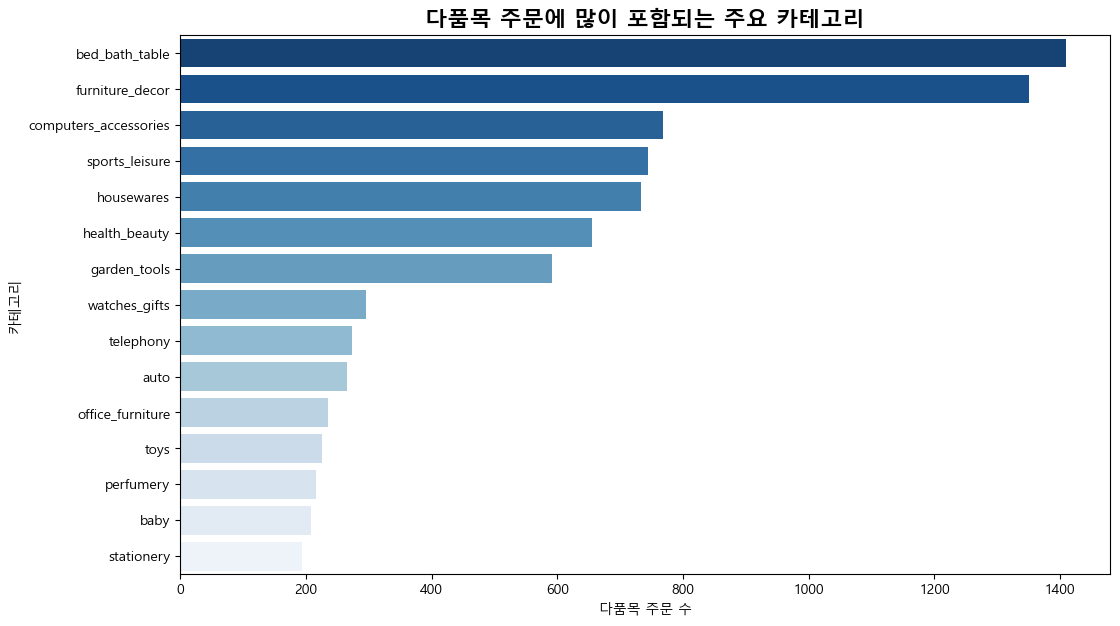

In [4]:
top_multi_categories = multi_category_summary.head(15).index

plt.figure(figsize=(12, 7))
sns.barplot(
    data=multi_category_summary.loc[top_multi_categories].reset_index(),
    y="category",
    x="order_count",
    palette="Blues_r"
)
plt.title("다품목 주문에 많이 포함되는 주요 카테고리", fontsize=16, weight="bold")
plt.xlabel("다품목 주문 수")
plt.ylabel("카테고리")
plt.show()

## 2. 주요 다품목 카테고리를 많이 필요로 하는 지역 파악

집하장에 어떤 품목을 적재할지는 지역 수요와 함께 판단해야 한다.

따라서 다품목 주문 주요 카테고리가 고객 권역별로 얼마나 필요한지 확인한다.

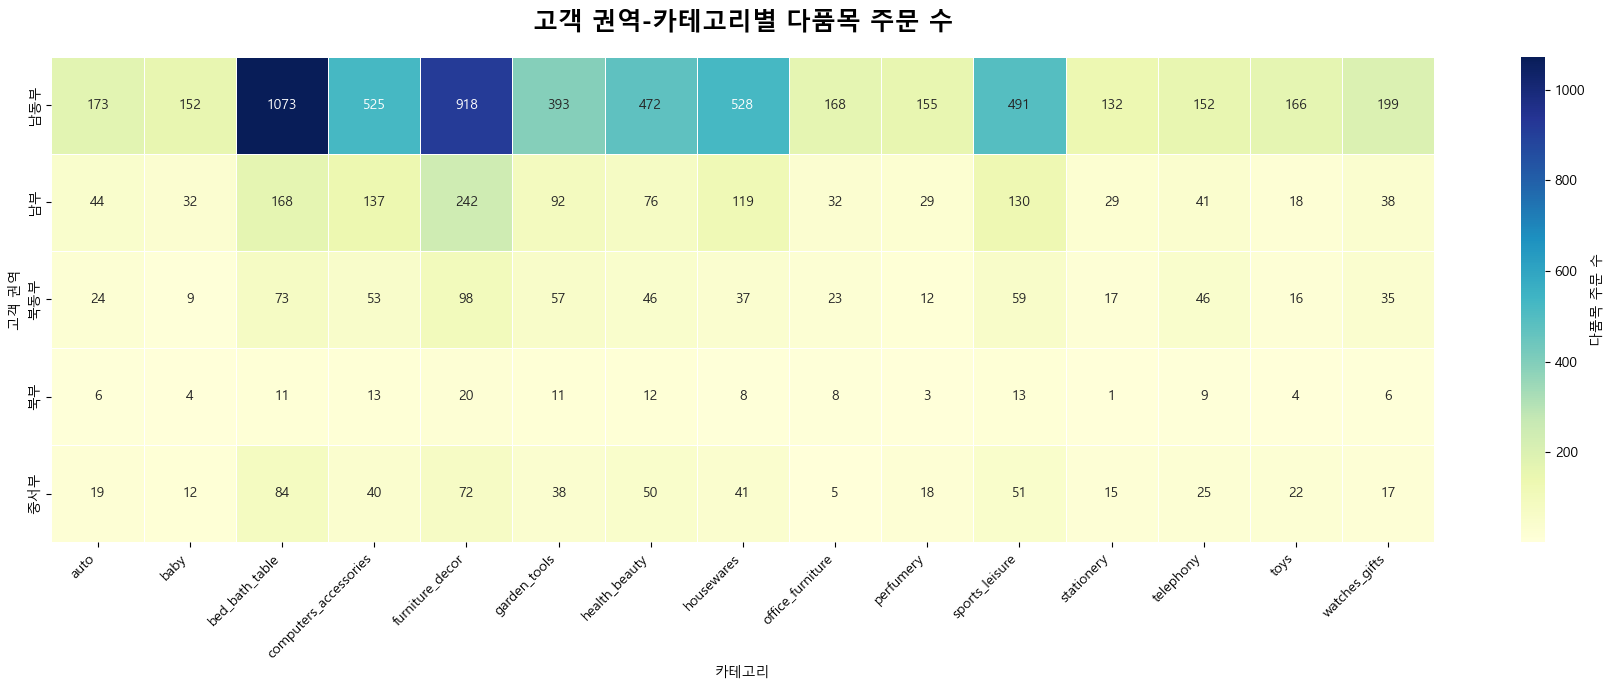

In [5]:
multi_top_df = multi_df[multi_df["category"].isin(top_multi_categories)].copy()

region_category_demand = multi_top_df.groupby(
    ["customer_region", "category"]
).agg(
    order_count=("order_id", "nunique"),
    item_count=("order_item_id", "count"),
    avg_review_score=("review_score_mean", "mean"),
    delay_rate=("is_delay", "mean"),
    avg_delivery_days=("delivery_days_clean", "mean")
).reset_index()

region_category_demand["delay_rate_pct"] = region_category_demand["delay_rate"] * 100

pivot_demand = region_category_demand.pivot_table(
    index="customer_region",
    columns="category",
    values="order_count",
    fill_value=0
)

plt.figure(figsize=(18, 7))
sns.heatmap(
    pivot_demand,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "다품목 주문 수"}
)
plt.title("고객 권역-카테고리별 다품목 주문 수", fontsize=18, weight="bold", pad=20)
plt.xlabel("카테고리")
plt.ylabel("고객 권역")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 3. 지역-카테고리별 월별 수요 예측 모델

## 분석 목적

집하장 운영을 위해서는 단순 과거 주문 수가 아니라 향후 수요를 예측해야 한다.

여기서는 다품목 주문에 자주 포함되는 주요 카테고리를 대상으로, 고객 권역과 카테고리별 월별 주문 수를 예측한다.

수요 예측에는 다음 정보를 사용한다.

- 연도
- 월
- 직전 1개월 주문 수
- 직전 2개월 주문 수
- 직전 3개월 주문 수
- 직전 3개월 평균 주문 수
- 평균 배송기간
- 배송 지연률
- 평균 리뷰점수

예측 모델은 Random Forest Regressor를 사용한다.

In [8]:
monthly_demand = multi_top_df.groupby(
    ["purchase_month_date", "customer_region", "category"],
    as_index=False
).agg(
    monthly_order_count=("order_id", "nunique"),
    monthly_item_count=("order_item_id", "count"),
    avg_delivery_days=("delivery_days_clean", "mean"),
    delay_rate=("is_delay", "mean"),
    avg_review_score=("review_score_mean", "mean")
)

monthly_demand["month"] = monthly_demand["purchase_month_date"].dt.month
monthly_demand["year"] = monthly_demand["purchase_month_date"].dt.year

monthly_demand = monthly_demand.sort_values(
    ["customer_region", "category", "purchase_month_date"]
).copy()

group_cols = ["customer_region", "category"]

monthly_demand["lag_1_order"] = monthly_demand.groupby(
    group_cols
)["monthly_order_count"].shift(1)

monthly_demand["lag_2_order"] = monthly_demand.groupby(
    group_cols
)["monthly_order_count"].shift(2)

monthly_demand["lag_3_order"] = monthly_demand.groupby(
    group_cols
)["monthly_order_count"].shift(3)

monthly_demand["rolling_3_order"] = monthly_demand[
    ["lag_1_order", "lag_2_order", "lag_3_order"]
].mean(axis=1)

model_demand_df = monthly_demand.dropna(subset=[
    "lag_1_order",
    "lag_2_order",
    "lag_3_order",
    "rolling_3_order"
]).copy()

model_demand_df.shape

(858, 14)

In [9]:
feature_cols = [
    "year",
    "month",
    "lag_1_order",
    "lag_2_order",
    "lag_3_order",
    "rolling_3_order",
    "avg_delivery_days",
    "delay_rate",
    "avg_review_score"
]

cat_cols = [
    "customer_region",
    "category"
]

X = pd.get_dummies(
    model_demand_df[feature_cols + cat_cols],
    columns=cat_cols,
    drop_first=False
)

y = model_demand_df["monthly_order_count"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

demand_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

demand_model.fit(X_train, y_train)

pred = demand_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 3.2248550564399125
RMSE: 6.443987188372416
R2: 0.8410484652833485


## 수요 예측 모델 해석

MAE는 예측 주문 수와 실제 주문 수의 평균 절대 오차를 의미한다.

RMSE는 큰 오차에 더 민감한 지표이다.

R²는 모델이 월별 주문 수 변동을 얼마나 설명하는지 나타낸다.

이 모델의 목적은 정확한 수요 예측 자체보다는, 지역-카테고리별 상대적인 수요 규모를 추정하여 집하장 사전재고 우선순위를 계산하는 것이다.

# 4. 집하장 사전재고 후보 산정

## 분석 목적

예상 수요, 지연률, 평균 배송기간, 리뷰점수를 함께 고려해 사전재고 우선순위를 계산한다.

사전재고 후보는 단순히 많이 팔리는 카테고리가 아니라, 다음 조건을 동시에 고려한다.

1. 예상 수요가 높다.
2. 배송 지연률이 높다.
3. 평균 배송기간이 길다.
4. 리뷰점수가 낮다.

즉, 많이 팔리면서 배송 문제가 크고 고객 만족도가 낮은 지역-카테고리 조합을 우선 후보로 선정한다.

In [10]:
latest_month = monthly_demand["purchase_month_date"].max()

latest_df = monthly_demand[
    monthly_demand["purchase_month_date"] == latest_month
].copy()

latest_df = latest_df.dropna(subset=[
    "lag_1_order",
    "lag_2_order",
    "lag_3_order",
    "rolling_3_order"
]).copy()

X_latest = pd.get_dummies(
    latest_df[feature_cols + cat_cols],
    columns=cat_cols,
    drop_first=False
)

X_latest = X_latest.reindex(columns=X.columns, fill_value=0)

latest_df["predicted_monthly_order"] = demand_model.predict(X_latest)

latest_df["stock_priority_score"] = (
    latest_df["predicted_monthly_order"].rank(pct=True) * 0.40 +
    latest_df["delay_rate"].rank(pct=True) * 0.25 +
    latest_df["avg_delivery_days"].rank(pct=True) * 0.20 +
    (1 - latest_df["avg_review_score"].rank(pct=True)) * 0.15
)

stock_candidates = latest_df.sort_values(
    "stock_priority_score",
    ascending=False
)

display(stock_candidates[[
    "customer_region",
    "category",
    "predicted_monthly_order",
    "delay_rate",
    "avg_delivery_days",
    "avg_review_score",
    "stock_priority_score"
]].head(20))

,customer_region,category,predicted_monthly_order,delay_rate,avg_delivery_days,avg_review_score,stock_priority_score
1034,남동부,furniture_decor,52.669139,0.142857,6.533333,3.580952,0.774510
1033,남동부,computers_accessories,24.363558,0.139535,8.790698,3.906977,0.761765
1049,남부,furniture_decor,13.099064,0.028571,10.114286,3.828571,0.751961
1032,남동부,bed_bath_table,59.769017,0.110345,6.413793,3.793103,0.734314
1065,북동부,watches_gifts,3.399113,0.285714,13.571429,3.142857,0.702941
1052,남부,housewares,10.697221,0.210526,8.315789,4.105263,0.676471
1035,남동부,garden_tools,20.921531,0.083333,5.625000,3.583333,0.669608
1074,중서부,health_beauty,4.429984,0.200000,14.600000,4.200000,0.668627
1048,남부,computers_accessories,6.856327,0.166667,11.083333,4.583333,0.664706
1037,남동부,housewares,48.211219,0.113636,4.897727,3.883721,0.662745


C:\Users\yiho1\AppData\Local\Temp\ipykernel_48784\189332321.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


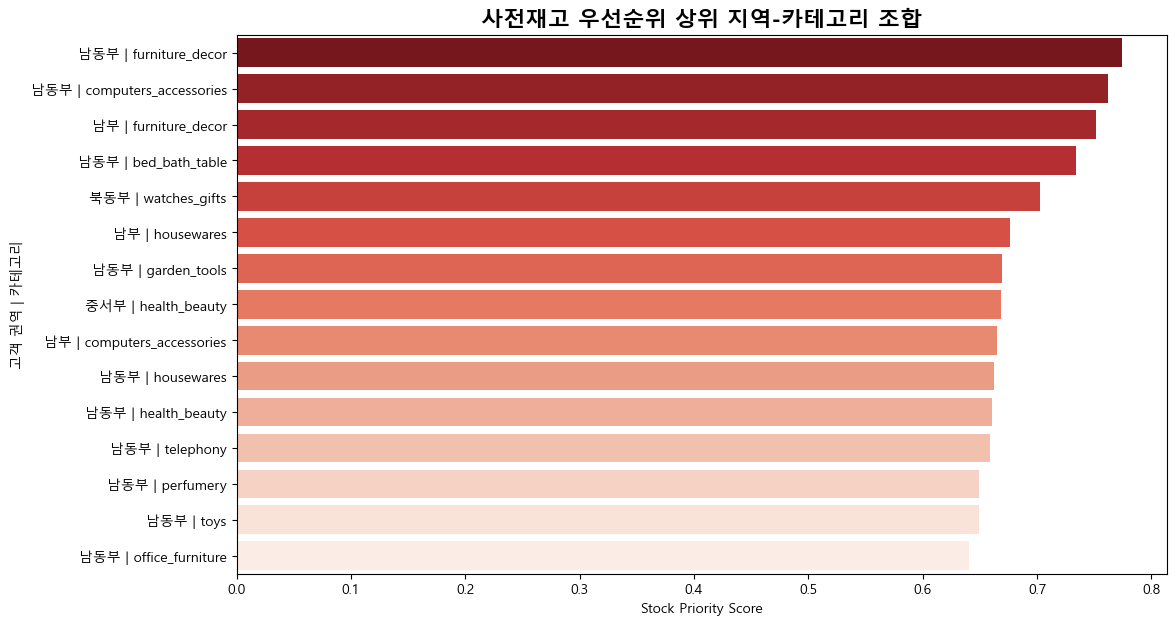

In [11]:
stock_plot = stock_candidates.head(15).copy()
stock_plot["label"] = (
    stock_plot["customer_region"].astype(str) +
    " | " +
    stock_plot["category"].astype(str)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=stock_plot,
    y="label",
    x="stock_priority_score",
    palette="Reds_r"
)

plt.title("사전재고 우선순위 상위 지역-카테고리 조합", fontsize=16, weight="bold")
plt.xlabel("Stock Priority Score")
plt.ylabel("고객 권역 | 카테고리")

plt.show()

## 사전재고 후보 해석

`stock_priority_score`가 높은 조합은 예상 수요가 많고, 배송 지연률이 높으며, 평균 배송기간이 길고, 리뷰점수가 낮은 조합이다.

따라서 해당 조합은 집하장에 사전재고를 배치할 우선 후보로 볼 수 있다.

이 결과는 “어떤 상품을 어느 지역 창고에 미리 보유해야 하는가?”에 대한 데이터 기반 근거가 된다.

# 5. 집하장 보유 재고량 추정

## 분석 목적

집하장 운영을 위해서는 어떤 품목을 보유할지뿐만 아니라, 얼마나 보유해야 하는지도 추정해야 한다.

여기서는 예측 월수요와 과거 수요 변동성을 활용해 권장 보유량을 계산한다.

권장 보유량은 다음과 같이 정의한다.

`권장 보유량 = 예측 월수요 + 1.65 × 월별 수요 표준편차`

여기서 1.65는 약 95% 서비스 수준을 가정한 안전계수이다.

In [12]:
demand_std = monthly_demand.groupby(
    ["customer_region", "category"]
)["monthly_order_count"].std().reset_index()

demand_std = demand_std.rename(columns={
    "monthly_order_count": "monthly_order_std"
})

stock_plan = stock_candidates.merge(
    demand_std,
    on=["customer_region", "category"],
    how="left"
)

stock_plan["monthly_order_std"] = stock_plan["monthly_order_std"].fillna(0)

stock_plan["recommended_stock"] = np.ceil(
    stock_plan["predicted_monthly_order"] +
    1.65 * stock_plan["monthly_order_std"]
)

display(stock_plan[[
    "customer_region",
    "category",
    "predicted_monthly_order",
    "monthly_order_std",
    "recommended_stock",
    "stock_priority_score"
]].head(20))

,customer_region,category,predicted_monthly_order,monthly_order_std,recommended_stock,stock_priority_score
0,남동부,furniture_decor,52.669139,21.654429,89.0,0.774510
1,남동부,computers_accessories,24.363558,21.498776,60.0,0.761765
2,남부,furniture_decor,13.099064,6.786892,25.0,0.751961
3,남동부,bed_bath_table,59.769017,28.749874,108.0,0.734314
4,북동부,watches_gifts,3.399113,0.975900,6.0,0.702941
5,남부,housewares,10.697221,3.413081,17.0,0.676471
6,남동부,garden_tools,20.921531,11.979258,41.0,0.669608
7,중서부,health_beauty,4.429984,2.249183,9.0,0.668627
8,남부,computers_accessories,6.856327,5.065906,16.0,0.664706
9,남동부,housewares,48.211219,15.573329,74.0,0.662745


C:\Users\yiho1\AppData\Local\Temp\ipykernel_48784\2571975767.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


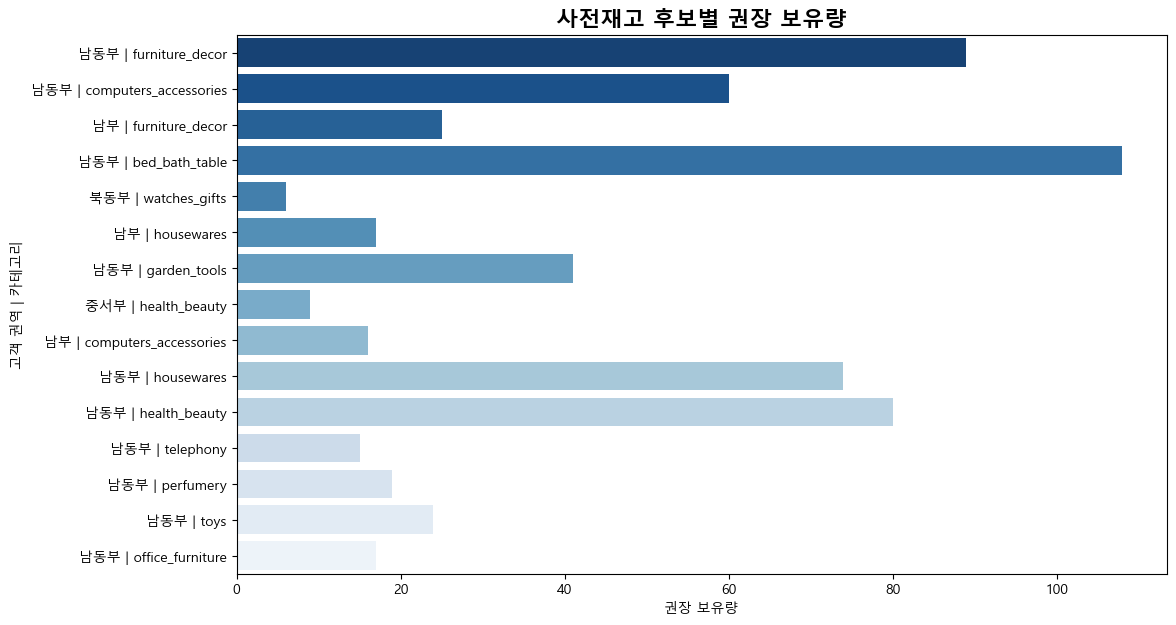

In [13]:
stock_amount_plot = stock_plan.head(15).copy()
stock_amount_plot["label"] = (
    stock_amount_plot["customer_region"].astype(str) +
    " | " +
    stock_amount_plot["category"].astype(str)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=stock_amount_plot,
    y="label",
    x="recommended_stock",
    palette="Blues_r"
)

plt.title("사전재고 후보별 권장 보유량", fontsize=16, weight="bold")
plt.xlabel("권장 보유량")
plt.ylabel("고객 권역 | 카테고리")

plt.show()

## 권장 보유량 해석

권장 보유량은 예상 월수요에 수요 변동성을 반영한 값이다.

수요가 많고 변동성이 큰 카테고리는 더 많은 안전재고가 필요하다.

이 결과는 집하장에 어떤 카테고리를 얼마나 보유해야 하는지에 대한 초기 기준으로 활용할 수 있다.

# 6. 집하장 후보 지역 산정

## 분석 목적

집하장 후보 지역은 단일 카테고리 기준이 아니라, 권역 전체의 수요와 배송 문제를 함께 고려해야 한다.

따라서 권역별로 다음 지표를 종합한다.

1. 예측 주문 수 합계
2. 권장 보유량 합계
3. 평균 배송 지연률
4. 평균 배송기간
5. 평균 리뷰점수
6. 사전재고 후보 카테고리 수

이를 바탕으로 집하장 우선순위 점수를 계산한다.

In [14]:
hub_region_summary = stock_plan.groupby("customer_region").agg(
    predicted_order_sum=("predicted_monthly_order", "sum"),
    recommended_stock_sum=("recommended_stock", "sum"),
    avg_delay_rate=("delay_rate", "mean"),
    avg_delivery_days=("avg_delivery_days", "mean"),
    avg_review_score=("avg_review_score", "mean"),
    category_count=("category", "nunique")
).reset_index()

hub_region_summary["hub_priority_score"] = (
    hub_region_summary["predicted_order_sum"].rank(pct=True) * 0.35 +
    hub_region_summary["avg_delay_rate"].rank(pct=True) * 0.25 +
    hub_region_summary["avg_delivery_days"].rank(pct=True) * 0.20 +
    (1 - hub_region_summary["avg_review_score"].rank(pct=True)) * 0.15 +
    hub_region_summary["category_count"].rank(pct=True) * 0.05
)

hub_region_summary = hub_region_summary.sort_values(
    "hub_priority_score",
    ascending=False
)

display(hub_region_summary)

,customer_region,predicted_order_sum,recommended_stock_sum,avg_delay_rate,avg_delivery_days,avg_review_score,category_count,hub_priority_score
0,남동부,369.333281,654.0,0.109479,6.405806,3.665798,15,0.75
4,중서부,33.595717,63.0,0.057143,9.580519,3.599711,11,0.68
2,북동부,22.418822,46.0,0.040816,11.219728,3.615646,7,0.56
1,남부,73.555760,146.0,0.028983,8.305785,4.212765,14,0.50
3,북부,8.271370,15.0,0.000000,13.800000,3.775000,4,0.36


C:\Users\yiho1\AppData\Local\Temp\ipykernel_48784\1070329694.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


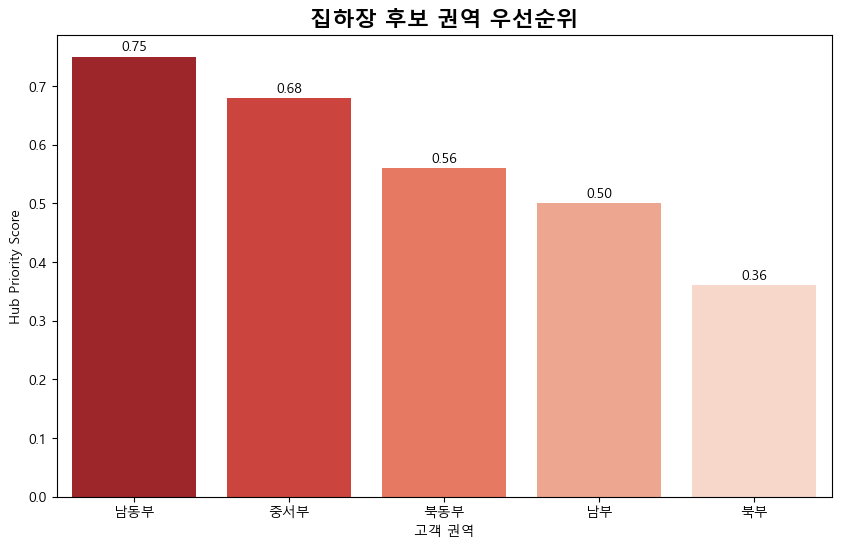

In [15]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=hub_region_summary,
    x="customer_region",
    y="hub_priority_score",
    palette="Reds_r"
)

plt.title("집하장 후보 권역 우선순위", fontsize=16, weight="bold")
plt.xlabel("고객 권역")
plt.ylabel("Hub Priority Score")

for i, row in hub_region_summary.reset_index(drop=True).iterrows():
    plt.text(
        i,
        row["hub_priority_score"] + 0.01,
        f'{row["hub_priority_score"]:.2f}',
        ha="center"
    )

plt.show()

## 집하장 후보 지역 해석

`hub_priority_score`가 높은 권역은 다음 특성을 가진다.

- 사전재고 대상 품목의 예상 수요가 많다.
- 배송 지연률이 높다.
- 평균 배송기간이 길다.
- 리뷰점수가 낮다.
- 여러 카테고리에서 사전재고 필요성이 나타난다.

따라서 해당 권역은 다품목 주문 복잡성과 배송 지연 문제를 줄이기 위한 집하장 후보 지역으로 볼 수 있다.

# 7. 예상 평점 상승 효과 추정

## 분석 목적

집하장 운영의 기대 효과는 실제 배송기간 단축과 평점 개선이다.

여기서는 단순 시뮬레이션 방식으로 배송기간이 줄어들었을 때 예상 리뷰점수가 얼마나 상승할 수 있는지 추정한다.

가정은 다음과 같다.

- 집하장 운영으로 다품목 주문의 배송기간이 10%, 20%, 30% 단축된다고 가정한다.
- 기존 데이터에서 배송기간, 상품 개수, 배송비, 주문금액과 리뷰점수의 관계를 학습한다.
- 배송기간만 단축된 상황을 시뮬레이션하여 예상 평점 상승폭을 계산한다.

In [16]:
review_model_df = multi_df.groupby("order_id", as_index=False).agg(
    delivery_days_clean=("delivery_days_clean", "first"),
    item_count=("item_count", "first"),
    freight_total=("freight_value", "sum"),
    price_total=("price", "sum"),
    review_score_mean=("review_score_mean", "first")
).replace([np.inf, -np.inf], np.nan).dropna()

X_review = review_model_df[
    ["delivery_days_clean", "item_count", "freight_total", "price_total"]
]

y_review = review_model_df["review_score_mean"]

rating_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)

rating_model.fit(X_review, y_review)

baseline_pred = rating_model.predict(X_review).mean()

uplift_results = []

for reduction in [0.10, 0.20, 0.30]:
    X_sim = X_review.copy()
    X_sim["delivery_days_clean"] = X_sim["delivery_days_clean"] * (1 - reduction)
    
    sim_pred = rating_model.predict(X_sim).mean()
    
    uplift_results.append({
        "delivery_days_reduction": f"{int(reduction * 100)}%",
        "baseline_pred_rating": baseline_pred,
        "simulated_pred_rating": sim_pred,
        "expected_rating_uplift": sim_pred - baseline_pred
    })

uplift_df = pd.DataFrame(uplift_results)

display(uplift_df)

,delivery_days_reduction,baseline_pred_rating,simulated_pred_rating,expected_rating_uplift
0,10%,3.636795,3.678392,0.041597
1,20%,3.636795,3.710885,0.074090
2,30%,3.636795,3.746277,0.109482


C:\Users\yiho1\AppData\Local\Temp\ipykernel_48784\679436122.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


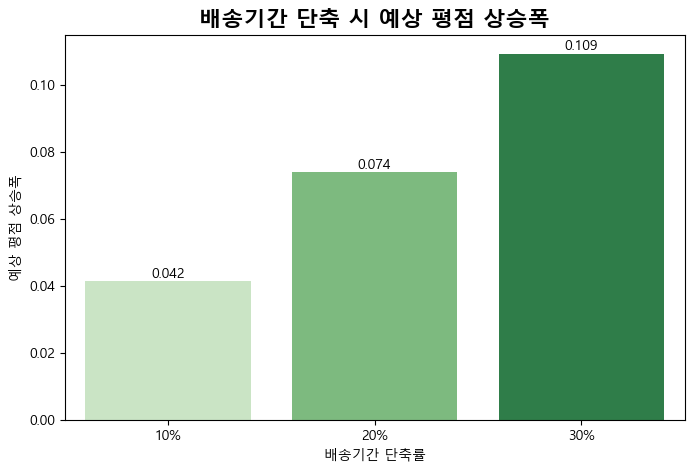

In [17]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=uplift_df,
    x="delivery_days_reduction",
    y="expected_rating_uplift",
    palette="Greens"
)

plt.title("배송기간 단축 시 예상 평점 상승폭", fontsize=16, weight="bold")
plt.xlabel("배송기간 단축률")
plt.ylabel("예상 평점 상승폭")

for i, row in uplift_df.iterrows():
    plt.text(
        i,
        row["expected_rating_uplift"] + 0.001,
        f'{row["expected_rating_uplift"]:.3f}',
        ha="center"
    )

plt.show()

## 예상 평점 상승 해석

이 시뮬레이션은 실제 정책 시행 결과가 아니라, 기존 데이터에서 학습한 배송기간과 리뷰점수의 관계를 바탕으로 한 추정치이다.

배송기간 단축률이 커질수록 예상 평점 상승폭이 증가한다면, 집하장 운영을 통한 배송 리드타임 단축이 고객 만족도 개선에 기여할 수 있음을 시사한다.

다만 실제 평점 상승은 배송기간 외에도 상품 품질, 판매자 응대, 가격, 고객 기대 수준 등의 영향을 받으므로, 본 결과는 정책 효과의 방향성을 보는 참고 지표로 해석해야 한다.

# 최종 해석 예시

본 분석은 다품목 주문이 배송 지연 및 평점 하락의 주요 원인으로 나타난 점에 착안하여, 집하장 운영과 사전재고 전략을 검토하였다.

먼저 다품목 주문에 자주 포함되는 주요 카테고리를 파악하고, 해당 카테고리를 많이 필요로 하는 고객 권역을 확인하였다.

이후 지역-카테고리별 월별 수요를 Random Forest 모델로 예측하고, 예상 수요와 과거 수요 변동성을 바탕으로 권장 보유 재고량을 산정하였다.

또한 예상 수요, 배송 지연률, 평균 배송기간, 리뷰점수를 종합하여 집하장 후보 권역의 우선순위를 계산하였다.

마지막으로 집하장 운영으로 배송기간이 단축될 경우 예상 리뷰점수가 얼마나 상승할 수 있는지 시뮬레이션하였다.

분석 결과는 집하장 운영 전략이 단순한 허브 추가가 아니라, 다음 기준을 함께 고려해야 함을 보여준다.

1. 다품목 주문 수요가 많은 지역
2. 다품목 주문에 자주 포함되는 카테고리
3. 배송 지연률이 높은 지역-카테고리 조합
4. 평균 배송기간이 긴 조합
5. 리뷰점수가 낮은 조합
6. 수요 변동성을 고려한 권장 보유량

따라서 집하장은 고수요·고지연 다품목 카테고리를 주요 고객 권역에 사전 배치하여, 실제 배송 리드타임과 주문 처리 복잡성을 줄이는 방향으로 운영하는 것이 적절하다.